# Aula 01




In [1]:
# conectar drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# librerias y modulos
import pandas as pd

# configuraciones
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
import warnings
warnings.filterwarnings("ignore")

In [3]:
# leer Dataset
URI = '/content/drive/MyDrive/Data_Science/Bootcamp Data Science/IA aplicada al Procesamiento de Lenguaje Natural - Bootcamp DS3/Lenguaje Natural: Introducción a NLP con análisis de sentimiento/colombian_elections.csv'
df = pd.read_csv(URI)
df.head()

,Unnamed: 0,tweet_id,tweetText,polarity_value,polarity_type,topic,set
0,2,ID:142391947707940864,@marodriguezb Gracias MAR,P,AGREEMENT,otros,train
1,3,ID:142416095012339712,"Off pensando en el regalito Sinde, la que se va de la SGAE cuando se van sus corruptos. Intento no sacar conclusiones (lo intento)",N,AGREEMENT,política,train
2,4,ID:142422495721562112,Conozco a alguien q es adicto al drama! Ja ja ja te suena d algo!,P,AGREEMENT,otros,train
3,6,ID:142483342040907776,Toca @crackoviadeTV3 . Grabación dl especial Navideño...Mari crismas!,P,AGREEMENT,entretenimiento,train
4,8,ID:142494476051562496,Buen día todos! Lo primero mandar un abrazo grande a Miguel y a su familia @libertadmontes Hoy podría ser un día para la grandeza humana.,P,AGREEMENT,otros,train


In [4]:
df = df[['tweetText', 'polarity_value']].rename(columns={'tweetText': 'texto',
                                                         'polarity_value': 'sentimiento'})

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5066 entries, 0 to 5065
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   texto        5066 non-null   object
 1   sentimiento  5066 non-null   object
dtypes: object(2)
memory usage: 79.3+ KB


In [6]:
# verificar si el target esta valanceado
df.sentimiento.value_counts()

sentimiento
P    2884
N    2182
Name: count, dtype: int64

In [7]:
# dicidiendo los datos en entrenamiento y test
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(df.texto, df.sentimiento, random_state=20)

In [9]:
# creando modelo
from sklearn.linear_model import LogisticRegression

In [10]:
# regresion = LogisticRegression()
# regresion.fit(X_train, y_train)

# acierto = regresion.score(X_test, y_test)
# print(f'El modelo tiene un {acierto*100:.2f}% de acierto')

In [11]:
# standarizar
df['sentimient'] = df['sentimiento'].replace(['N', 'P'], [0, 1])

In [12]:
df.head()

,texto,sentimiento,sentimient
0,@marodriguezb Gracias MAR,P,1
1,"Off pensando en el regalito Sinde, la que se va de la SGAE cuando se van sus corruptos. Intento no sacar conclusiones (lo intento)",N,0
2,Conozco a alguien q es adicto al drama! Ja ja ja te suena d algo!,P,1
3,Toca @crackoviadeTV3 . Grabación dl especial Navideño...Mari crismas!,P,1
4,Buen día todos! Lo primero mandar un abrazo grande a Miguel y a su familia @libertadmontes Hoy podría ser un día para la grandeza humana.,P,1


# Aula 02

## Bag of words


###**nltk.tokenize**
es un módulo de la biblioteca Natural Language Toolkit (NLTK) en Python, que se utiliza para dividir texto en unidades más pequeñas, como palabras, oraciones o párrafos. Esta operación se conoce como "tokenización". La tokenización es una parte fundamental del procesamiento de lenguaje natural (NLP), ya que permite analizar y manipular el texto de manera más eficaz.

**Usos de nltk.tokenize**

1. División de texto en oraciones: Permite separar un párrafo en oraciones individuales.
2. División de texto en palabras: Permite separar una oración en palabras individuales.
3. Tokenización de palabras con reglas específicas: Puede manejar contracciones, puntuación, y otros elementos lingüísticos según el idioma específico.

In [13]:
from nltk import tokenize

In [14]:
frase = 'Hola mundo, como estas?'

token_puntuacion = tokenize.WordPunctTokenizer()
token_frase = token_puntuacion.tokenize(frase)
token_frase

['Hola', 'mundo', ',', 'como', 'estas', '?']

### **matriz esparsa** (o matriz dispersa)
 es una matriz en la que la mayoría de los elementos son cero. Las matrices esparsas se utilizan comúnmente en aplicaciones donde la matriz es muy grande, pero solo unos pocos elementos tienen valores diferentes de cero. Debido a su estructura, las matrices esparsas permiten almacenar y manejar grandes volúmenes de datos de manera más eficiente tanto en términos de memoria como de tiempo de procesamiento.

**Características de las matrices esparsas:**
1. Alta proporción de ceros: La mayoría de los elementos son ceros, y solo unos pocos son valores no nulos.
2. Eficiencia en almacenamiento: Almacenar únicamente los elementos no nulos junto con sus posiciones puede ahorrar una cantidad significativa de espacio de memoria.
3. Eficiencia en cálculos: Operaciones matemáticas pueden ser optimizadas para trabajar solo con los elementos no nulos, mejorando el rendimiento.

## BOG ejemplo en Python

###**CountVectorizer**  
es una clase del módulo feature_extraction.text de la biblioteca scikit-learn (también conocida como sklearn) en Python. Se utiliza para convertir una colección de documentos de texto en una matriz de conteos de términos, lo que se conoce como una "bolsa de palabras" (bag-of-words).

**Qué es CountVectorizer**
CountVectorizer transforma texto en una representación numérica, donde cada fila de la matriz resultante representa un documento y cada columna representa un término (palabra) del vocabulario del corpus. Los valores en la matriz son los conteos de la frecuencia de los términos en cada documento.

**Para qué sirve CountVectorizer**
CountVectorizer es útil para:

1. Preprocesamiento de texto: Convertir texto en datos numéricos para su análisis y modelado.
2. Modelos de aprendizaje automático: Crear matrices de características para entrenar modelos de clasificación, clustering, y otras tareas de NLP (procesamiento de lenguaje natural).
3. Análisis de texto: Realizar análisis estadísticos y extracción de características de textos.

info: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

In [16]:
texto = ['Las propuestas son buenas', 'las propuestas no son buenas']
# esto creara una matriz esparza
vextorizador = CountVectorizer(lowercase=False)

bag_of_words = vextorizador.fit_transform(texto)

In [17]:
bag_of_words

<2x6 sparse matrix of type '<class 'numpy.int64'>'
	with 9 stored elements in Compressed Sparse Row format>

In [18]:
bag_of_words.shape

(2, 6)

In [19]:
''' iportante en esta parte podemos optener las palabras de las frases pasadas
al vectorizador con el metodo get_feature_names_out()
importante mensionar que la funcion contiene parametros por defecto,
sindo asi que Las y las aunque son diferentes en la mayuscula el parametro
lowercase = True por defecto las transforma todas en minuscula'''
vextorizador.get_feature_names_out()

array(['Las', 'buenas', 'las', 'no', 'propuestas', 'son'], dtype=object)

info: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sparse.from_spmatrix.html

In [20]:
matriz = pd.DataFrame.sparse.from_spmatrix(bag_of_words,
                                           columns=vextorizador.get_feature_names_out())
matriz

,Las,buenas,las,no,propuestas,son
0,1,1,0,0,1,1
1,0,1,1,1,1,1


## BOG aplicado a caso real

In [21]:
vextorizador_ = CountVectorizer(max_features=100)

bag_of_words_ = vextorizador_.fit_transform(df['texto'])

In [22]:
bag_of_words_.shape

(5066, 100)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(bag_of_words_, df['sentimient'], random_state=20)

In [24]:
regresion = LogisticRegression()
regresion.fit(X_train, y_train)

acierto = regresion.score(X_test, y_test)
print(f'El modelo tiene un {acierto*100:.2f}% de acierto')

El modelo tiene un 70.01% de acierto


# Aula 03


##  Función

In [25]:
def clasificador(df, col_texto, col_categoria):
    vextorizador = CountVectorizer(max_features=100)
    bag_of_words = vextorizador.fit_transform(df[col_texto])

    X_train, X_test, y_train, y_test = train_test_split(bag_of_words, df[col_categoria], random_state=20)
    regresion = LogisticRegression()
    regresion.fit(X_train, y_train)

    acierto = regresion.score(X_test, y_test)
    return print(f'El modelo tiene un {acierto*100:.2f}% de acierto')

In [26]:
clasificador(df, 'texto', 'sentimient')

El modelo tiene un 70.01% de acierto


### Word cloud

**word cloud (nube de palabras)**

es una visualización gráfica de palabras que se utiliza para representar la frecuencia o importancia de palabras dentro de un texto o conjunto de textos. En una word cloud, las palabras más frecuentes o significativas se muestran con mayor tamaño o peso visual, mientras que las palabras menos frecuentes se muestran más pequeñas. Esta herramienta es útil para identificar rápidamente las palabras clave o temas principales en un texto.

**Usos de Word Cloud**
1. Análisis de texto: Para identificar rápidamente las palabras más frecuentes en un conjunto de datos textuales.
2. Visualización de datos: Para representar de manera visual y atractiva las tendencias en el uso del lenguaje.
3. Presentaciones: Para destacar los puntos clave o temas principales de un discurso o documento.
4. Exploración de datos: Para obtener una visión general del contenido de grandes volúmenes de texto.

###**WordCloud**
de la biblioteca wordcloud en Python se utiliza para generar visualizaciones gráficas de palabras, conocidas como nubes de palabras (word clouds). Estas visualizaciones muestran palabras con diferentes tamaños en función de su frecuencia o importancia dentro de un texto. Las nubes de palabras son herramientas útiles para resumir y analizar grandes volúmenes de texto, permitiendo identificar rápidamente las palabras clave o temas principales.

**Qué es WordCloud**
WordCloud es una clase que facilita la creación de nubes de palabras. Esta clase convierte texto en una visualización donde las palabras más frecuentes aparecen más grandes y las menos frecuentes son más pequeñas.

**Para qué sirve WordCloud**
1. Análisis de texto: Para identificar rápidamente las palabras más frecuentes en un conjunto de datos textuales.
2. Visualización de datos: Para representar de manera visual y atractiva las tendencias en el uso del lenguaje.
3. Presentaciones: Para destacar los puntos clave o temas principales de un discurso o documento.
4. Exploración de datos: Para obtener una visión general del contenido de grandes volúmenes de texto.
**Cómo funciona WordCloud**
1. Preprocesamiento del texto: Filtra y limpia el texto de entrada, eliminando palabras comunes (stop words) si se especifica.
2. Conteo de palabras: Calcula la frecuencia de cada palabra en el texto.
3. Generación de la nube de palabras: Asigna tamaños a las palabras en función de su frecuencia y las coloca en la visualización de manera que las palabras más frecuentes son más grandes y prominentes.

In [27]:
from wordcloud import WordCloud

In [28]:
palabras = ' '.join(palabras for palabras in df['texto'])

In [29]:
palabras

'@marodriguezb Gracias MAR Off pensando en el regalito Sinde, la que se va de la SGAE cuando se van sus corruptos. Intento no sacar conclusiones (lo intento) Conozco a alguien q es adicto al drama! Ja ja ja te suena d algo! Toca @crackoviadeTV3 . Grabación dl especial Navideño...Mari crismas! Buen día todos! Lo primero mandar un abrazo grande a Miguel y a su familia @libertadmontes Hoy podría ser un día para la grandeza humana. Desde el escaño. Todo listo para empezar #endiascomohoy en el Congreso http://t.co/Mu2yIgCb Bdías. EM no se ira de puente. Si vosotros os vais no dejeis de llevar la tableta o el PC y desde luego Orbyt. De momento no digo más. Un sistema económico q recorta dinero para prestaciones sociales y refuerza con billón y medio d euros a los bancos, no necesita repensarse? #programascambiados caca d ajuste Buen viernes “@adri_22_22: #programascambiados es TT gracias a @Carlos_Latre” GRACIAS POR EL BUEN RATO AMIGOS!!;) La Universidad confía en De la Calle para encarar su

In [30]:
len(palabras)

556945

In [31]:
import matplotlib.pyplot as plt
%matplotlib inline

In [32]:
def plot_cloud(wordcloud):
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off");

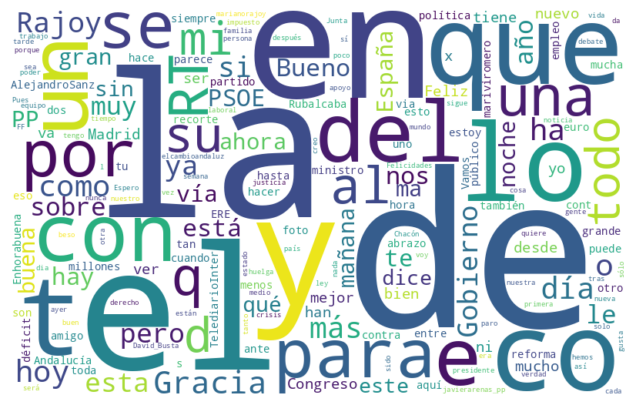

In [33]:
# plotar las palabras mas frecuentes en el texto
wordcloud = WordCloud(background_color='white',
                      width=800,
                      height=500,
                      collocations=False).generate(palabras)
plot_cloud(wordcloud)

## Optimizando la Word cloud

1. mejora en la funcion plot_cloud
2. agregar hiperparametros a wordcloud width=800, height=500, collocations=False

## Separando positivo - negativo

In [34]:
df_negativo = df[df['sentimient'] == 0]
df_negativo.head()

,texto,sentimiento,sentimient
1,"Off pensando en el regalito Sinde, la que se va de la SGAE cuando se van sus corruptos. Intento no sacar conclusiones (lo intento)",N,0
8,#programascambiados caca d ajuste,N,0
13,abcdesevilla.es: Recio no tiene «indicios potentes» para denunciar a los responsables de los ERE http://t.co/wlDSs1yQ,N,0
14,"abcdesevilla.es: Cuatro altos cargos de Empleo, denunciados por retirar la prejubilación a extrabajadores http://t.co/LWHxzbuB",N,0
15,La marcha atrás del PP en posponer devolución CCAA es un resbalón. Debería asumir fallo y no mentir diciendo que no conoce estado cuentas,N,0


In [35]:
df_positivo = df[df['sentimient'] == 1]
df_positivo.head()

,texto,sentimiento,sentimient
0,@marodriguezb Gracias MAR,P,1
2,Conozco a alguien q es adicto al drama! Ja ja ja te suena d algo!,P,1
3,Toca @crackoviadeTV3 . Grabación dl especial Navideño...Mari crismas!,P,1
4,Buen día todos! Lo primero mandar un abrazo grande a Miguel y a su familia @libertadmontes Hoy podría ser un día para la grandeza humana.,P,1
5,Desde el escaño. Todo listo para empezar #endiascomohoy en el Congreso http://t.co/Mu2yIgCb,P,1


In [36]:
def plot_cloud_neg(df):
    df_negativo = df[df['sentimient'] == 0]

    palabras = ' '.join(palabras for palabras in df_negativo['texto'])

    wordcloud = WordCloud(background_color='white',
                      width=800,
                      height=500,
                      collocations=False).generate(palabras)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off");

In [37]:
def plot_cloud_pos(df):
    df_positivo = df[df['sentimient'] == 1]

    palabras = ' '.join(palabras for palabras in df_positivo['texto'])

    wordcloud = WordCloud(background_color='white',
                      width=800,
                      height=500,
                      collocations=False).generate(palabras)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off");

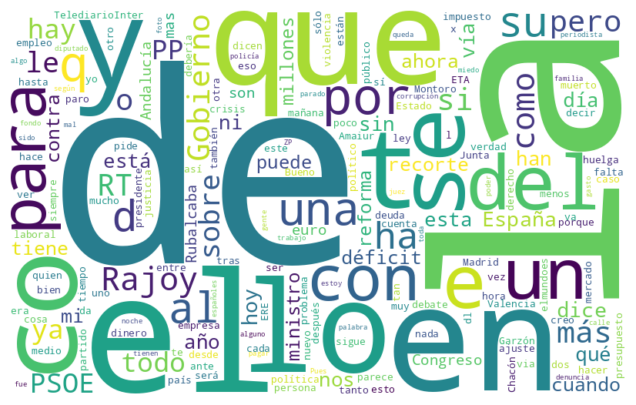

In [38]:
plot_cloud_neg(df)

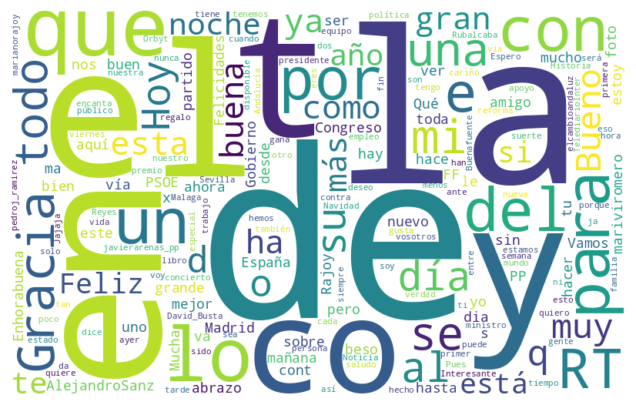

In [39]:
plot_cloud_pos(df)

# Aula 04

## Conociendo la bib NLTK

### **nltk (Natural Language Toolkit)**
es una biblioteca en Python que proporciona herramientas y recursos para el procesamiento de lenguaje natural (NLP). Esta biblioteca es ampliamente utilizada para tareas como tokenización, etiquetado de partes de la oración, análisis sintáctico, análisis de sentimientos, y mucho más.

**Qué es nltk**

nltk es una colección de módulos que facilita la manipulación de texto y la realización de tareas de procesamiento de lenguaje natural. Incluye corpora (colecciones de texto), algoritmos de procesamiento de texto, y herramientas para el análisis lingüístico.

**Para qué sirve nltk**

1. Tokenización: Dividir texto en palabras, oraciones, párrafos, etc.
2. Etiquetado POS (Part-of-Speech): Asignar etiquetas gramaticales a cada palabra (sustantivo, verbo, adjetivo, etc.).
3. Análisis sintáctico: Construcción de árboles sintácticos a partir de oraciones.
4. Stemming y Lemmatization: Reducir palabras a su forma raíz.
5. Clasificación y Análisis de Sentimientos: Clasificación de texto y análisis de sentimientos.
6. Trabajo con corpora: Manipulación y análisis de grandes colecciones de textos preprocesados.

In [40]:
import nltk

In [41]:
frase = ['el candidati es bueno', 'el candidato es malo']
frequencia = nltk.FreqDist(frase)
frequencia

FreqDist({'el candidati es bueno': 1, 'el candidato es malo': 1})

## Tokenizacion - Concepto

**nltk.tokenize**
es un módulo de la biblioteca NLTK (Natural Language Toolkit) en Python, diseñado para dividir cadenas de texto en partes más pequeñas, como oraciones o palabras. Esto es útil para el procesamiento del lenguaje natural (PLN), ya que permite analizar y trabajar con el texto de una manera más granular.

Aquí tienes una descripción de los principales métodos disponibles en nltk.tokenize:

1. **word_tokenize(texto):**Divide una cadena de texto en palabras individuales. Toma en cuenta la puntuación y los espacios para determinar los límites de las palabras.

2. **sent_tokenize(texto):** Divide una cadena de texto en oraciones. Utiliza modelos para identificar los límites de las oraciones en función de las convenciones del lenguaje natural.

3. **TweetTokenizer:** Es una clase especializada para tokenizar texto de Twitter, teniendo en cuenta las particularidades de ese tipo de texto, como menciones de usuarios, hashtags, y emoticones.

4. **regexp_tokenize(texto, patrón):** Utiliza expresiones regulares para dividir el texto en tokens según un patrón específico.

In [42]:
from nltk import tokenize

In [43]:
frase2 = 'hoal chicos y chicas'

token_espacio = tokenize.WhitespaceTokenizer()
frase_token = token_espacio.tokenize(frase2)

In [44]:
frase_token

['hoal', 'chicos', 'y', 'chicas']

## Tokenizacion aplicado dataset

In [46]:
fras_token = token_espacio.tokenize(palabras)
frequencia = nltk.FreqDist(fras_token)

In [47]:
df_frecuencia = pd.DataFrame({
    'palabra': list(frequencia.keys()),
    'frecuencia': list(frequencia.values())
})
df_frecuencia.head()

,palabra,frecuencia
0,@marodriguezb,3
1,Gracias,119
2,MAR,1
3,Off,1
4,pensando,5


In [49]:
# df_frecuencia.sort_values('frecuencia', ascending=False).head(10)
df_frecuencia.nlargest(columns='frecuencia', n=10)

,palabra,frecuencia
13,de,3863
9,la,2365
6,el,1929
5,en,1886
26,a,1886
57,y,1655
10,que,1575
107,los,934
170,del,863
20,no,713


# Aula 05

## Barras - Exploracion

In [50]:
import seaborn as sns

[Text(0, 0.5, 'conteo')]

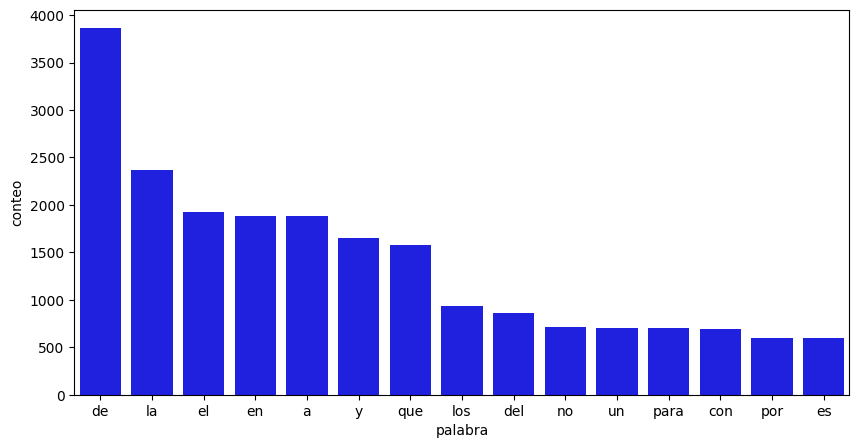

In [52]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_frecuencia.nlargest(columns='frecuencia', n=15),
                 x='palabra',
                 y='frecuencia',
                 color = 'blue')
ax.set(ylabel='conteo')

##  Histograma - Barras

In [55]:
def histo_barras(df, texto, cantidad):
    palabras = ' '.join(palabras for palabras in df['texto'])

    fras_token = token_espacio.tokenize(palabras)
    frequencia = nltk.FreqDist(fras_token)

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=df_frecuencia.nlargest(columns='frecuencia', n=cantidad),
                    x='palabra',
                    y='frecuencia',
                    color = 'blue')
    ax.set(ylabel='conteo')

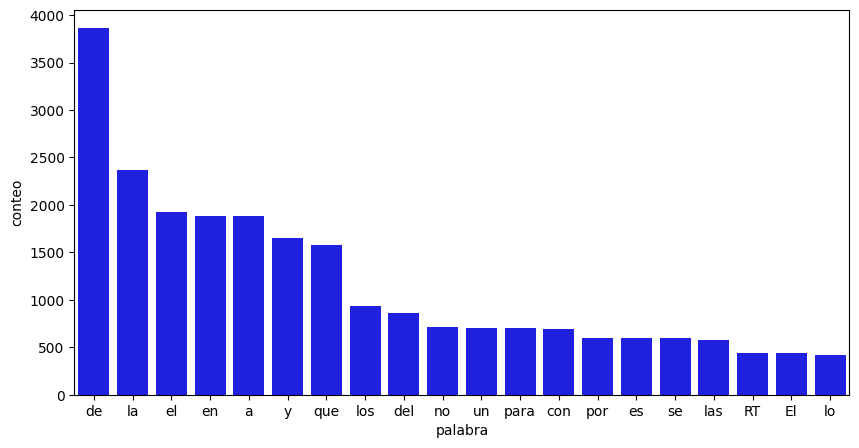

In [56]:
histo_barras(df, df['texto'], 20)

##  Stop words

###**El módulo nltk.corpus.stopwords**

proporciona una lista de palabras comunes en un idioma determinado que generalmente se consideran irrelevantes para el análisis de texto y que se pueden eliminar del texto durante el preprocesamiento. Estas palabras se conocen como "stopwords".

Las stopwords son palabras como "el", "la", "de", "en", "un", etc., que aparecen con alta frecuencia en el lenguaje pero que tienen poco valor semántico por sí solas y, por lo tanto, a menudo se eliminan del texto durante el análisis de texto para mejorar la precisión de las tareas de procesamiento del lenguaje natural (PLN) como la clasificación de texto, la agrupación de documentos, etc.

*Hay veces que cuando usan algún tipo de lenguaje español o portugués va a decir: “No tenemos el diccionario, no tenemos ese lenguaje en el notebook”. Entonces tienen que dar, como ya les dije **nltk download** y ponen entre paréntesis, por ejemplo, sopwords. Ahí va a bajar todas las stopwords de todos los lenguajes.*

In [57]:
from nltk.corpus import stopwords

In [61]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [62]:
irrelevantes = nltk.corpus.stopwords.words('spanish')

In [63]:
print(irrelevantes)

['de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 'un', 'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 'sus', 'le', 'ya', 'o', 'este', 'sí', 'porque', 'esta', 'entre', 'cuando', 'muy', 'sin', 'sobre', 'también', 'me', 'hasta', 'hay', 'donde', 'quien', 'desde', 'todo', 'nos', 'durante', 'todos', 'uno', 'les', 'ni', 'contra', 'otros', 'ese', 'eso', 'ante', 'ellos', 'e', 'esto', 'mí', 'antes', 'algunos', 'qué', 'unos', 'yo', 'otro', 'otras', 'otra', 'él', 'tanto', 'esa', 'estos', 'mucho', 'quienes', 'nada', 'muchos', 'cual', 'poco', 'ella', 'estar', 'estas', 'algunas', 'algo', 'nosotros', 'mi', 'mis', 'tú', 'te', 'ti', 'tu', 'tus', 'ellas', 'nosotras', 'vosotros', 'vosotras', 'os', 'mío', 'mía', 'míos', 'mías', 'tuyo', 'tuya', 'tuyos', 'tuyas', 'suyo', 'suya', 'suyos', 'suyas', 'nuestro', 'nuestra', 'nuestros', 'nuestras', 'vuestro', 'vuestra', 'vuestros', 'vuestras', 'esos', 'esas', 'estoy', 'estás', 'está', 'estamos', 'estáis', 'están', 'e

In [64]:
frase_procces = list()

for opinion in df.texto:
    nueva_frase = list()

    palabras_texto = token_espacio.tokenize(opinion)

    for palabra in palabras_texto:
        if palabra not in irrelevantes:
            nueva_frase.append(palabra)

    frase_procces.append(' '.join(nueva_frase))


In [65]:
df['tatamiento_1'] = frase_procces
df.head()

,texto,sentimiento,sentimient,tatamiento_1
0,@marodriguezb Gracias MAR,P,1,@marodriguezb Gracias MAR
1,"Off pensando en el regalito Sinde, la que se va de la SGAE cuando se van sus corruptos. Intento no sacar conclusiones (lo intento)",N,0,"Off pensando regalito Sinde, va SGAE van corruptos. Intento sacar conclusiones (lo intento)"
2,Conozco a alguien q es adicto al drama! Ja ja ja te suena d algo!,P,1,Conozco alguien q adicto drama! Ja ja ja suena d algo!
3,Toca @crackoviadeTV3 . Grabación dl especial Navideño...Mari crismas!,P,1,Toca @crackoviadeTV3 . Grabación dl especial Navideño...Mari crismas!
4,Buen día todos! Lo primero mandar un abrazo grande a Miguel y a su familia @libertadmontes Hoy podría ser un día para la grandeza humana.,P,1,Buen día todos! Lo primero mandar abrazo grande Miguel familia @libertadmontes Hoy podría ser día grandeza humana.


In [66]:
clasificador(df, 'tatamiento_1', 'sentimient')

El modelo tiene un 68.67% de acierto
